# 데이터 및 패키지 로딩

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

In [ ]:
import os
import urllib.request

path_to_file = 'sherlock.txt'
if not os.path.exists(path_to_file):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/hyerica-bdml/class-2026-nlp/refs/heads/main/data/sherlock.txt',
        path_to_file)

with open(path_to_file) as f:
    lines = f.read().splitlines()
    
for line in lines[:20]:
    print(line)

A STUDY IN SCARLET.





PART I.
(Being a reprint from the reminiscences of JOHN H. WATSON, M.D., late of the Army Medical Department.) 2






CHAPTER I. MR. SHERLOCK HOLMES.
IN the year 1878 I took my degree of Doctor of Medicine of the University of London, and proceeded to Netley to go through the course prescribed for surgeons in the army. Having completed my studies there, I was duly attached to the Fifth Northumberland Fusiliers as Assistant Surgeon. The regiment was stationed in India at the time, and before I could join it, the second Afghan war had broken out. On landing at Bombay, I learned that my corps had advanced through the passes, and was already deep in the enemy’s country. I followed, however, with many other officers who were in the same situation as myself, and succeeded in reaching Candahar in safety, where I found my regiment, and at once entered upon my new duties.

The campaign brought honours and promotion to many, but for me it had nothing but misfortune and 

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Younghoon\AppData\Roaming\nltk_data...


True

# 학습 데이터 준비

생성 데이터
* vocab: 단어 -> ID
* inverse_vocab: ID -> 단어
* input_targets: 타깃 주변 단어 ID의 배열
* input_centers: 중심 단어 ID의 배열

In [ ]:
vocab, index = {}, 1  # start indexing from 1
vocab['<pad>'] = 0  # add a padding token
preprocessed_tokens = []

for sentence in lines:
    tokens = [lemmatizer.lemmatize(token.lower(), pos = "v") 
              for token in nltk.tokenize.word_tokenize(sentence) 
              if token.isalpha()]
    preprocessed_tokens.append(tokens)
    
    for token in tokens:
        if token not in vocab:
            vocab[token] = index
            index += 1

inverse_vocab = {index: token for token, index in vocab.items()}
vocab_size = len(vocab)
print(vocab_size)

4496


In [ ]:
sequences = []
for tokens in preprocessed_tokens:
    seq = [vocab[token] for token in tokens]
    sequences.append(seq)

In [ ]:
def skipgrams(sequence, window_size):
    pairs = []
    for i, target in enumerate(sequence):
        window_start = max(0, i - window_size)
        window_end = min(len(sequence), i + window_size + 1)
        for j in range(window_start, window_end):
            if j != i:
                pairs.append([target, sequence[j]])
    return pairs

window_size = 2
positive_skip_grams = skipgrams(sequences[0], window_size=window_size)


[]


In [ ]:
targets, centers = [], []

window_size = 5
for sequence in sequences:
    positive_skip_grams = skipgrams(sequence, window_size=window_size)
    
    if len(positive_skip_grams) < 2:
        continue

    _targets, _centers = zip(*positive_skip_grams)
    targets.extend(_targets)
    centers.extend(_centers)

In [ ]:
input_targets = np.array(targets)
input_centers = np.array(centers)

# 모델 정의

* NCELoss: 주변단어 가중치 U의 모델 파라미터를 포함한 노이즈 샘플링, NCE 로스 계산 모듈
* Word2VecNCE: NCELoss 및 임베딩 벡터 V의 모델 파라미터를 포함한 NCE 로스 계산 모듈

In [ ]:
class NCELoss(nn.Module):
    def __init__(self, num_classes, embedding_dim, n_neg_samples=100):
        super().__init__()
        ## --- fill here ---

    def forward(self, embeddings, targets):
        ## --- fill here ---

        return (pos_loss + neg_loss).mean()

In [ ]:
hidden_dim = 32

class Word2VecNCE(nn.Module):
    ## --- fill here ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Word2VecNCE(vocab_size, hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters())
print(model)

Word2VecNCE(
  (word_embedding): Embedding(4496, 32)
  (nce): NCE()
)


# 학습

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

centers_tensor = torch.tensor(input_centers, dtype=torch.long)
targets_tensor = torch.tensor(input_targets, dtype=torch.long)

dataset = TensorDataset(centers_tensor, targets_tensor)
loader = DataLoader(dataset, batch_size=100, shuffle=True)

epochs = 20
model.train()
for epoch in range(epochs):
    total_loss = 0.0
    for batch_centers, batch_targets in loader:
        ## --- fill here ---

    print(f"Epoch {epoch + 1}/{epochs} - loss: {total_loss / len(loader):.4f}")

Epoch 1/20 - loss: 78.1169
Epoch 2/20 - loss: 7.7268
Epoch 3/20 - loss: 4.0916
Epoch 4/20 - loss: 3.5563
Epoch 5/20 - loss: 3.4585
Epoch 6/20 - loss: 3.4245
Epoch 7/20 - loss: 3.4029
Epoch 8/20 - loss: 3.3866
Epoch 9/20 - loss: 3.3693
Epoch 10/20 - loss: 3.3551
Epoch 11/20 - loss: 3.3409
Epoch 12/20 - loss: 3.3292
Epoch 13/20 - loss: 3.3169
Epoch 14/20 - loss: 3.3033
Epoch 15/20 - loss: 3.2931
Epoch 16/20 - loss: 3.2824
Epoch 17/20 - loss: 3.2698
Epoch 18/20 - loss: 3.2590
Epoch 19/20 - loss: 3.2481
Epoch 20/20 - loss: 3.2397


In [24]:
model.eval()

def get_embeddings(word_ids):
    with torch.no_grad():
        ids = torch.tensor(word_ids, dtype=torch.long, device=device)
        return model.word_embedding(ids).cpu().numpy()

In [25]:
first_500_words = np.arange(500)
final_embeddings = get_embeddings(first_500_words)
final_embeddings.shape

(500, 32)

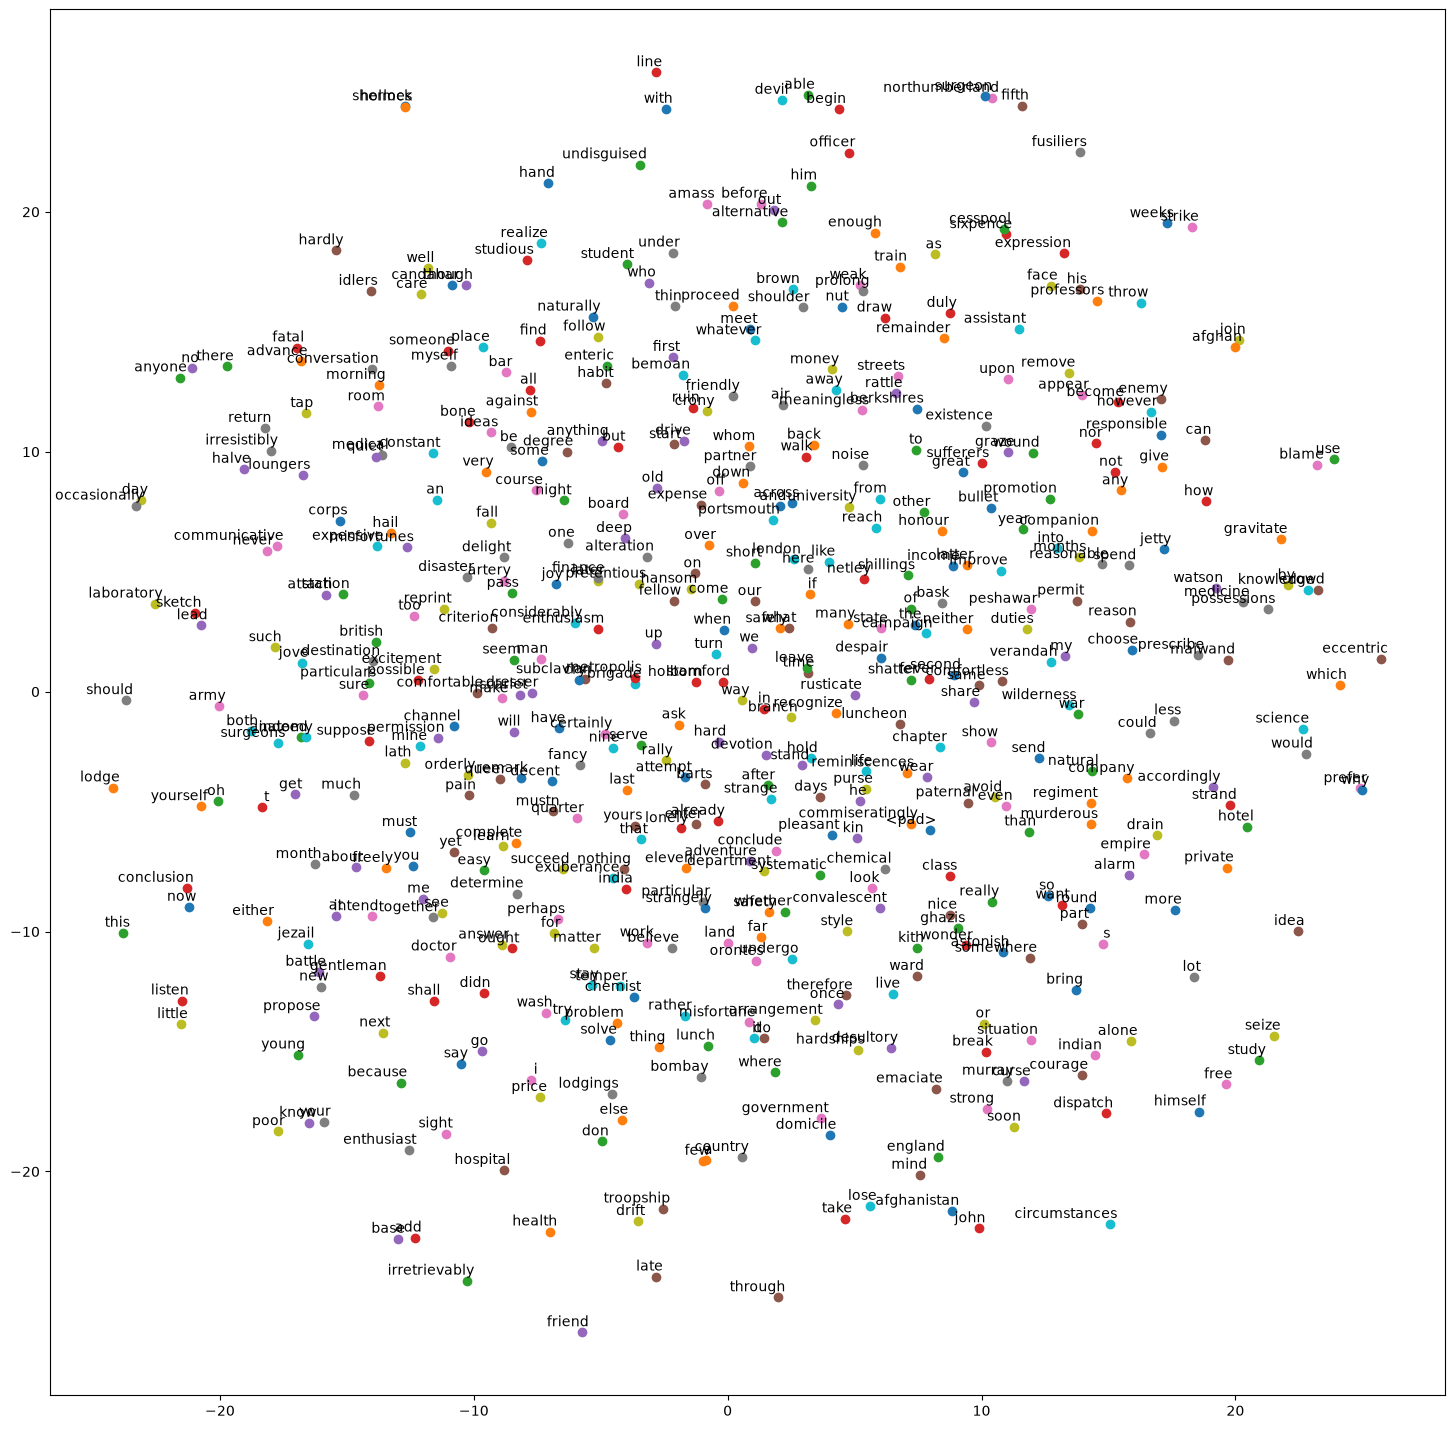

In [29]:
def plot_with_labels(low_dim_embs, labels):
    assert low_dim_embs.shape[0] >= len(
        labels), 'More labels than embeddings'
    plt.figure(figsize=(18, 18))  # in inches
    for i, label in enumerate(labels):
        x, y = low_dim_embs[i, :]
        plt.scatter(x, y)
        plt.annotate(label,
                     xy=(x, y),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
    plt.show()


from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(perplexity=30, n_components=2,
            init='pca', method='exact')
n_embeddings = 500
low_dim_embeddings = tsne.fit_transform(final_embeddings)
labels = [inverse_vocab[i] for i in range(n_embeddings)]

plot_with_labels(low_dim_embeddings, labels)